In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report)
from sklearn.inspection import DecisionBoundaryDisplay
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

In [8]:
def create_train_val_test_split(X, y, train_size=0.64, val_size=0.16, test_size=0.20):

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=RANDOM_STATE
    )
    
    val_relative_size = val_size / (train_size + val_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_relative_size, 
        stratify=y_train_val, random_state=RANDOM_STATE
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test
def evaluate_model(y_true, y_pred, model_name="Model"):

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }
    
    print(f"\n{model_name} Performance:")
    print("-" * 40)
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    
    return metrics, cm

def plot_decision_boundary(model, X, y, title="Decision Boundary", ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='black', s=50, alpha=0.8)
    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(*scatter.legend_elements(), title="Classes")
    return ax

def plot_depth_curve(X_train, y_train, X_val, y_val, title="Decision Tree Depth Analysis"):
    depths = range(1, 21)
    train_scores = []
    val_scores = []
    
    for depth in depths:
        dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
        dt.fit(X_train, y_train)
        train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
        val_scores.append(accuracy_score(y_val, dt.predict(X_val)))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(depths, train_scores, 'o-', label='Training Accuracy', linewidth=2)
    ax1.plot(depths, val_scores, 's-', label='Validation Accuracy', linewidth=2)
    ax1.set_xlabel('Max Depth', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title(title, fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    gap = np.array(train_scores) - np.array(val_scores)
    ax2.plot(depths, gap, 'ro-', linewidth=2)
    ax2.set_xlabel('Max Depth', fontsize=12)
    ax2.set_ylabel('Train-Val Accuracy Gap', fontsize=12)
    ax2.set_title('Overfitting Measure', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame({'Depth': depths, 'Train_Accuracy': train_scores, 
                        'Val_Accuracy': val_scores, 'Gap': gap})

def plot_regularization_curve(X_train, y_train, X_val, y_val, title="Logistic Regression Regularization Analysis"):
    C_values = [0.001, 0.01, 0.1, 1, 10, 100]
    train_scores_l1 = []
    val_scores_l1 = []
    train_scores_l2 = []
    val_scores_l2 = []
    
    for C in C_values:
        
        lr_l1 = LogisticRegression(penalty='l1', C=C, solver='liblinear', 
                                   random_state=RANDOM_STATE)
        lr_l1.fit(X_train, y_train)
        train_scores_l1.append(accuracy_score(y_train, lr_l1.predict(X_train)))
        val_scores_l1.append(accuracy_score(y_val, lr_l1.predict(X_val)))
        
        lr_l2 = LogisticRegression(penalty='l2', C=C, solver='liblinear', 
                                   random_state=RANDOM_STATE)
        lr_l2.fit(X_train, y_train)
        train_scores_l2.append(accuracy_score(y_train, lr_l2.predict(X_train)))
        val_scores_l2.append(accuracy_score(y_val, lr_l2.predict(X_val)))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].semilogx(C_values, train_scores_l1, 'o-', label='Training', linewidth=2)
    axes[0].semilogx(C_values, val_scores_l1, 's-', label='Validation', linewidth=2)
    axes[0].set_xlabel('C (Regularization strength)', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('L1 Regularization', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].semilogx(C_values, train_scores_l2, 'o-', label='Training', linewidth=2)
    axes[1].semilogx(C_values, val_scores_l2, 's-', label='Validation', linewidth=2)
    axes[1].set_xlabel('C (Regularization strength)', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('L2 Regularization', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def tune_logistic_regression(X_train, y_train, X_val, y_val, use_poly=False, degree=2):
    results = []
    best_model = None
    best_score = -1
    best_params = None
    
    penalties = ['l1', 'l2']
    C_values = [0.001, 0.01, 0.1, 1, 10]
    
    for penalty in penalties:
        for C in C_values:
            
            steps = []
            if use_poly:
                steps.append(('poly', PolynomialFeatures(degree=degree, include_bias=False)))
            steps.extend([
                ('scaler', StandardScaler()),
                ('lr', LogisticRegression(penalty=penalty, C=C, solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
            ])
            
            model = Pipeline(steps)
            model.fit(X_train, y_train)
            
            train_acc = accuracy_score(y_train, model.predict(X_train))
            val_acc = accuracy_score(y_val, model.predict(X_val))
            
            results.append({
                'penalty': penalty,
                'C': C,
                'train_accuracy': train_acc,
                'val_accuracy': val_acc
            })
            
            if val_acc > best_score:
                best_score = val_acc
                best_model = model
                best_params = {'penalty': penalty, 'C': C}
    
    results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
    return best_model, results_df, best_params

def tune_decision_tree(X_train, y_train, X_val, y_val):
    results = []
    best_model = None
    best_score = -1
    best_params = None
    
    max_depths = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, None]
    min_samples_splits = [2, 5, 10, 20]
    min_samples_leaves = [1, 2, 4, 8]
    
    for max_depth in max_depths:
        for min_samples_split in min_samples_splits:
            for min_samples_leaf in min_samples_leaves:
                dt = DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    random_state=RANDOM_STATE
                )
                dt.fit(X_train, y_train)
                
                train_acc = accuracy_score(y_train, dt.predict(X_train))
                val_acc = accuracy_score(y_val, dt.predict(X_val))
                
                results.append({
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'min_samples_leaf': min_samples_leaf,
                    'train_accuracy': train_acc,
                    'val_accuracy': val_acc
                })
                
                if val_acc > best_score:
                    best_score = val_acc
                    best_model = dt
                    best_params = {
                        'max_depth': max_depth,
                        'min_samples_split': min_samples_split,
                        'min_samples_leaf': min_samples_leaf
                    }
    
    results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
    return best_model, results_df, best_params


def run_experiment(dataset_name, X, y, dataset_type="numerical", use_poly=False):
  
    X_train, X_val, X_test, y_train, y_val, y_test = create_train_val_test_split(X, y)
    print(f"\nData split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='black', s=50)
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')
    axes[0].set_title(f'{dataset_name}\nOriginal Data', fontweight='bold')
    
    class_dist = pd.Series(y).value_counts().sort_index()
    axes[1].bar(['Class 0', 'Class 1'], class_dist.values, color=['red', 'green'], alpha=0.7)
    axes[1].set_title('Class Distribution', fontweight='bold')
    axes[1].set_ylabel('Count')
    
    for i, v in enumerate(class_dist.values):
        axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    best_lr, lr_results, lr_params = tune_logistic_regression(X_train, y_train, X_val, y_val, use_poly=use_poly)
    print(f"Best parameters: {lr_params}")
    print("\nTop 5 configurations:")
    print(lr_results.head(5).to_string(index=False))
    
    best_dt, dt_results, dt_params = tune_decision_tree(X_train, y_train, X_val, y_val)
    print(f"Best parameters: {dt_params}")
    print("\nTop 5 configurations:")
    print(dt_results.head(5).to_string(index=False))

    depth_df = plot_depth_curve(X_train, y_train, X_val, y_val, f"{dataset_name}\nDecision Tree Depth Analysis")

    plot_regularization_curve(X_train, y_train, X_val, y_val, f"{dataset_name}\nRegularization Analysis")
   
    y_pred_lr = best_lr.predict(X_test)
    lr_metrics, lr_cm = evaluate_model(y_test, y_pred_lr, "Logistic Regression")
    
    y_pred_dt = best_dt.predict(X_test)
    dt_metrics, dt_cm = evaluate_model(y_test, y_pred_dt, "Decision Tree")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    plot_decision_boundary(best_lr, X_test, y_test, f"Logistic Regression Decision Boundary\n{dataset_name}", ax=axes[0])
    plot_decision_boundary(best_dt, X_test, y_test, f"Decision Tree Decision Boundary\n{dataset_name}", ax=axes[1])
    
    plt.tight_layout()
    plt.show()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')
    
    sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    axes[1].set_title('Decision Tree\nConfusion Matrix', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'dataset_name': dataset_name,
        'best_lr': best_lr,
        'best_dt': best_dt,
        'lr_params': lr_params,
        'dt_params': dt_params,
        'lr_metrics': lr_metrics,
        'dt_metrics': dt_metrics,
        'lr_results': lr_results,
        'dt_results': dt_results,
        'depth_df': depth_df,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred_lr': y_pred_lr,
        'y_pred_dt': y_pred_dt
    }

def create_summary_table(all_results):
    summary_data = []
    
    for result in all_results:
        summary_data.append({
            'Dataset': result['dataset_name'],
            'Model': 'Logistic Regression',
            'Accuracy': result['lr_metrics']['Accuracy'],
            'Precision': result['lr_metrics']['Precision'],
            'Recall': result['lr_metrics']['Recall'],
            'F1-Score': result['lr_metrics']['F1-Score']
        })
        summary_data.append({
            'Dataset': result['dataset_name'],
            'Model': 'Decision Tree',
            'Accuracy': result['dt_metrics']['Accuracy'],
            'Precision': result['dt_metrics']['Precision'],
            'Recall': result['dt_metrics']['Recall'],
            'F1-Score': result['dt_metrics']['F1-Score']
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    for i, metric in enumerate(metrics):
        ax = axes[i//2, i%2]
        pivot_data = summary_df.pivot(index='Dataset', columns='Model', values=metric)
        pivot_data.plot(kind='bar', ax=ax, rot=45, alpha=0.8)
        ax.set_title(f'{metric} Comparison', fontweight='bold', fontsize=14)
        ax.set_ylabel(metric)
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', fontsize=9)
    
    plt.suptitle('Model Performance Comparison Across All Datasets', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return summary_df


Data split: Train=384, Val=96, Test=120


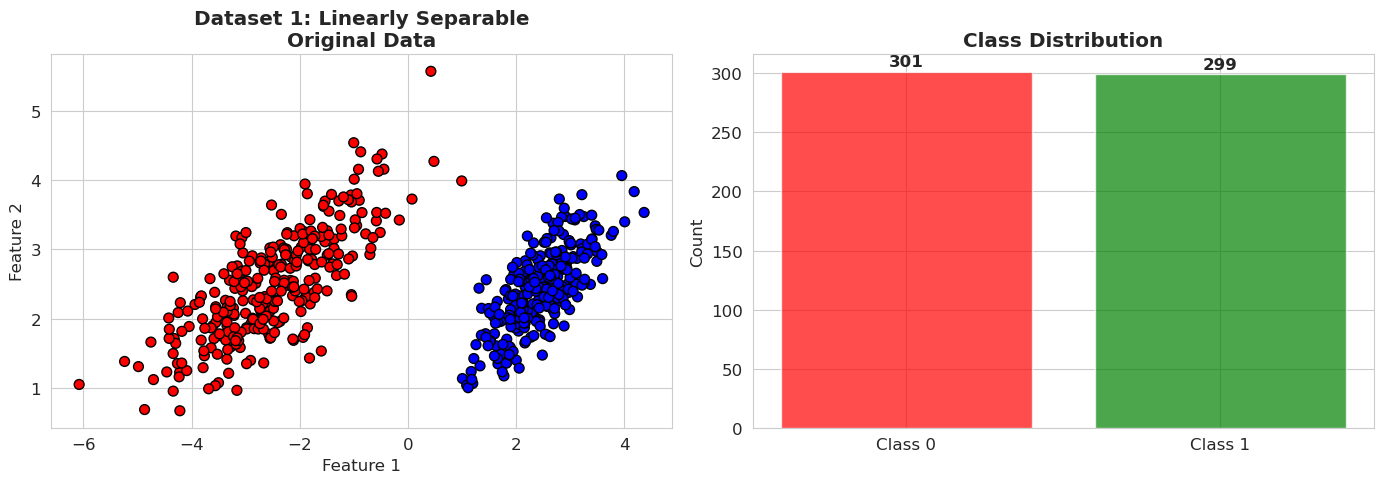

Best parameters: {'penalty': 'l1', 'C': 0.01}

Top 5 configurations:
penalty      C  train_accuracy  val_accuracy
     l1  0.010        0.992188           1.0
     l1  0.100        0.997396           1.0
     l1  1.000        0.997396           1.0
     l1 10.000        0.997396           1.0
     l2  0.001        0.994792           1.0
Best parameters: {'max_depth': 1, 'min_samples_split': 2, 'min_samples_leaf': 1}

Top 5 configurations:
 max_depth  min_samples_split  min_samples_leaf  train_accuracy  val_accuracy
       1.0                  2                 1        0.997396           1.0
       6.0                 10                 4        0.997396           1.0
      10.0                  2                 4        0.997396           1.0
       8.0                 20                 8        0.997396           1.0
       8.0                 20                 4        0.997396           1.0


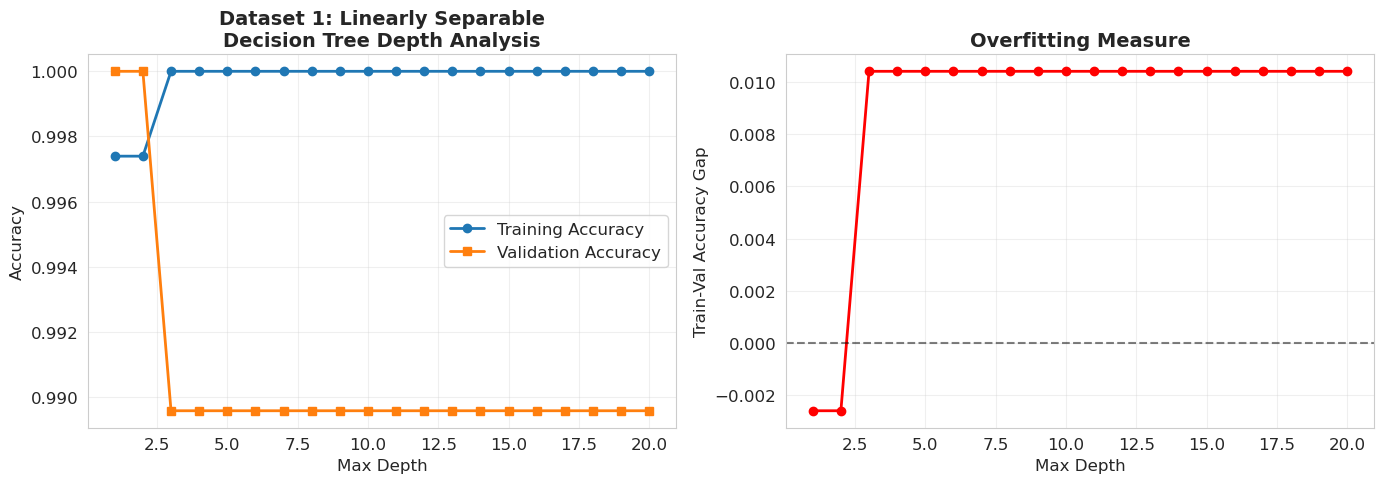

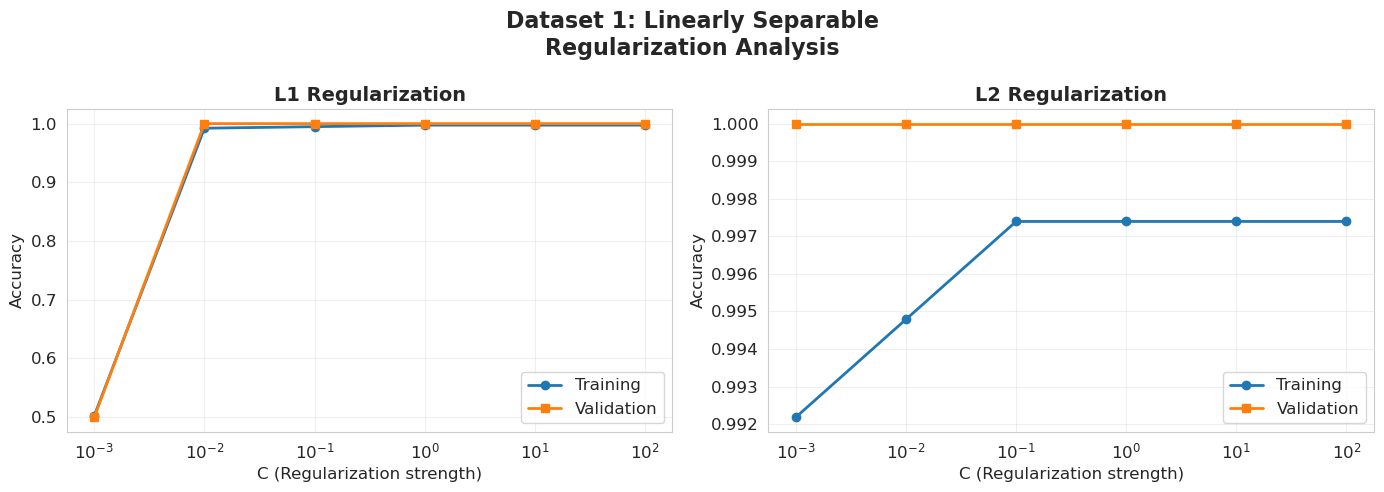


Logistic Regression Performance:
----------------------------------------
Accuracy: 0.9833
Precision: 0.9677
Recall: 1.0000
F1-Score: 0.9836

Confusion Matrix:
[[58  2]
 [ 0 60]]

Decision Tree Performance:
----------------------------------------
Accuracy: 0.9917
Precision: 0.9836
Recall: 1.0000
F1-Score: 0.9917

Confusion Matrix:
[[59  1]
 [ 0 60]]


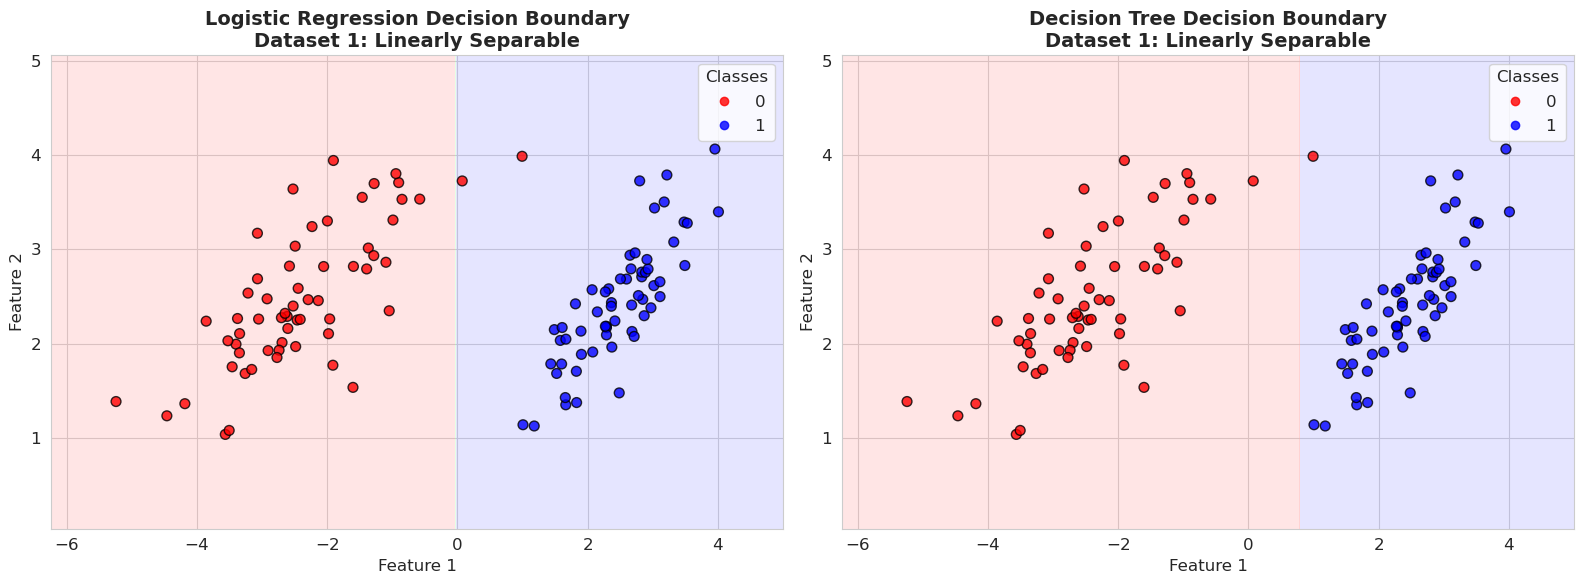

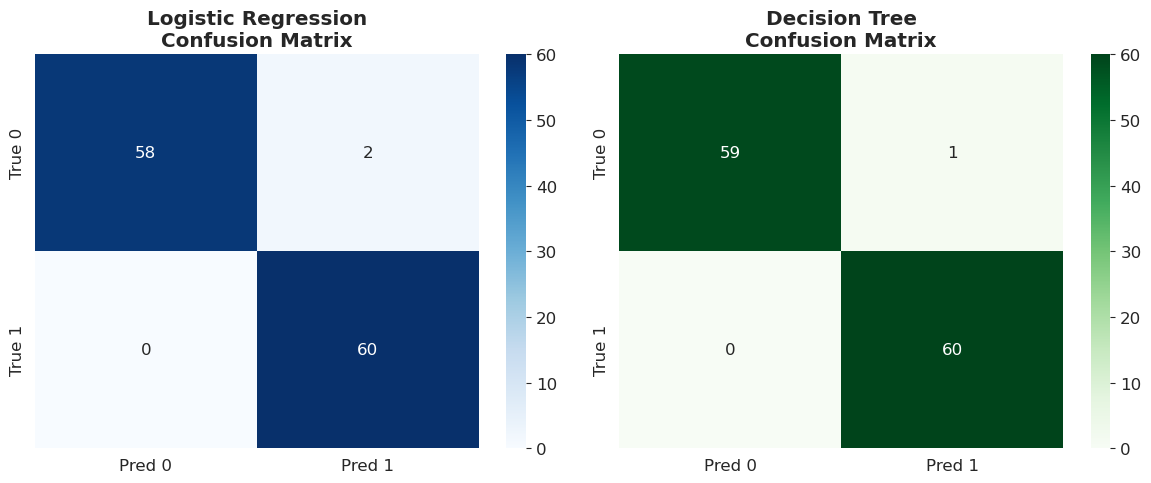

In [9]:
X1, y1 = make_classification(
    n_samples=600,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2.5,  
    flip_y=0.01,    
    random_state=RANDOM_STATE
)


results1 = run_experiment("Dataset 1: Linearly Separable", X1, y1, use_poly=False)


Data split: Train=512, Val=128, Test=160


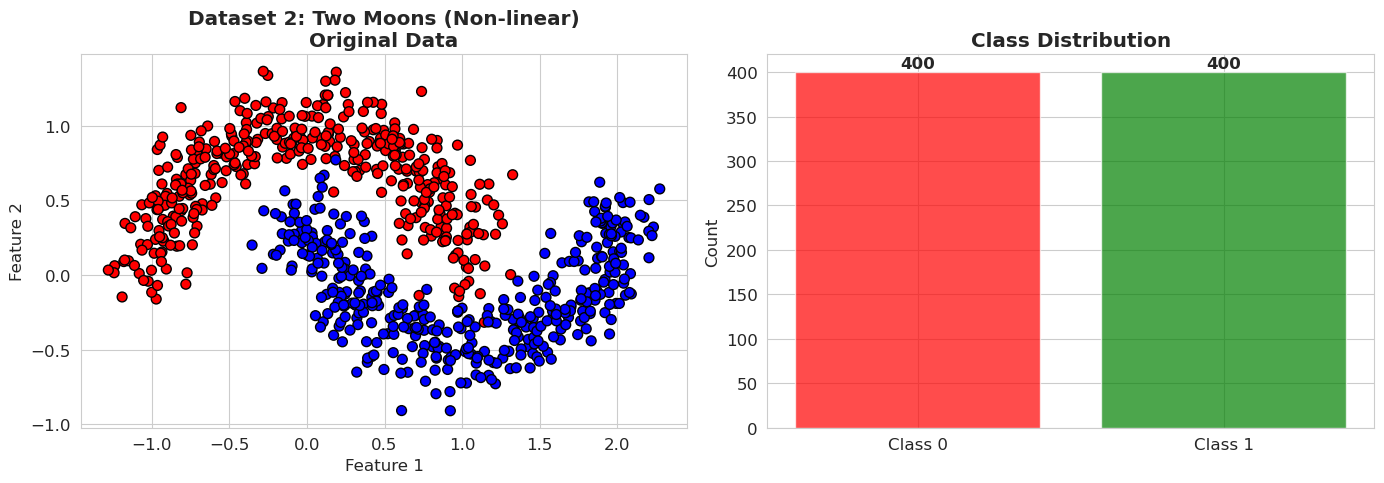

Best parameters: {'penalty': 'l1', 'C': 0.1}

Top 5 configurations:
penalty    C  train_accuracy  val_accuracy
     l1  0.1        0.875000      0.859375
     l1  1.0        0.876953      0.859375
     l1 10.0        0.875000      0.859375
     l2  0.1        0.873047      0.859375
     l2  1.0        0.873047      0.859375
Best parameters: {'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 4}

Top 5 configurations:
 max_depth  min_samples_split  min_samples_leaf  train_accuracy  val_accuracy
      12.0                  2                 4        0.994141      0.992188
      12.0                 10                 2        0.994141      0.992188
      10.0                  5                 4        0.994141      0.992188
       8.0                  5                 1        0.998047      0.992188
      15.0                  2                 4        0.994141      0.992188


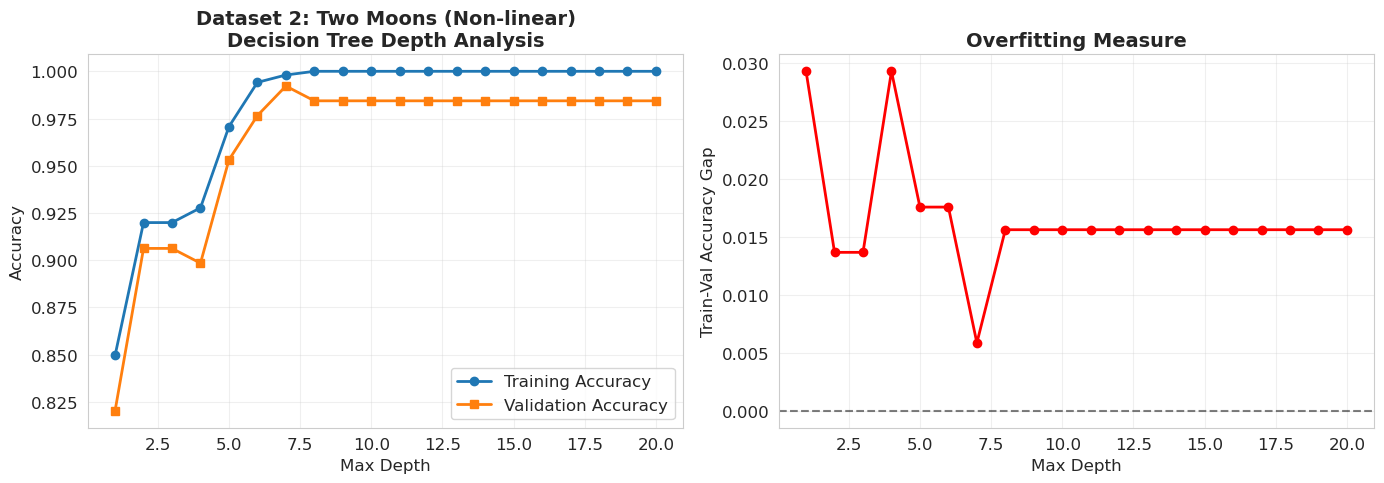

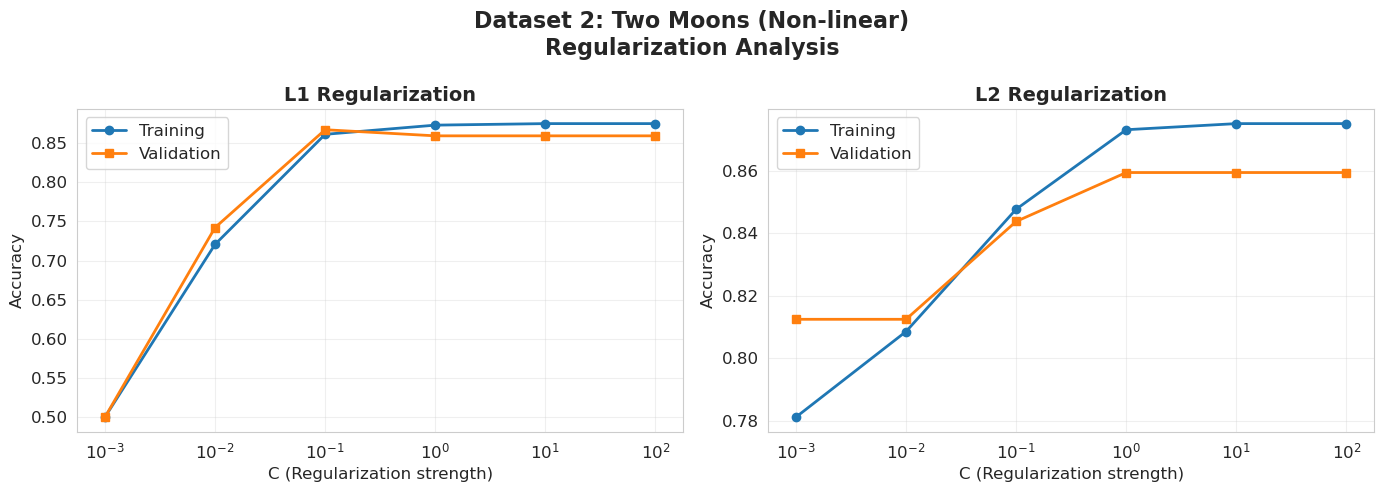


Logistic Regression Performance:
----------------------------------------
Accuracy: 0.9000
Precision: 0.9103
Recall: 0.8875
F1-Score: 0.8987

Confusion Matrix:
[[73  7]
 [ 9 71]]

Decision Tree Performance:
----------------------------------------
Accuracy: 0.9938
Precision: 0.9877
Recall: 1.0000
F1-Score: 0.9938

Confusion Matrix:
[[79  1]
 [ 0 80]]


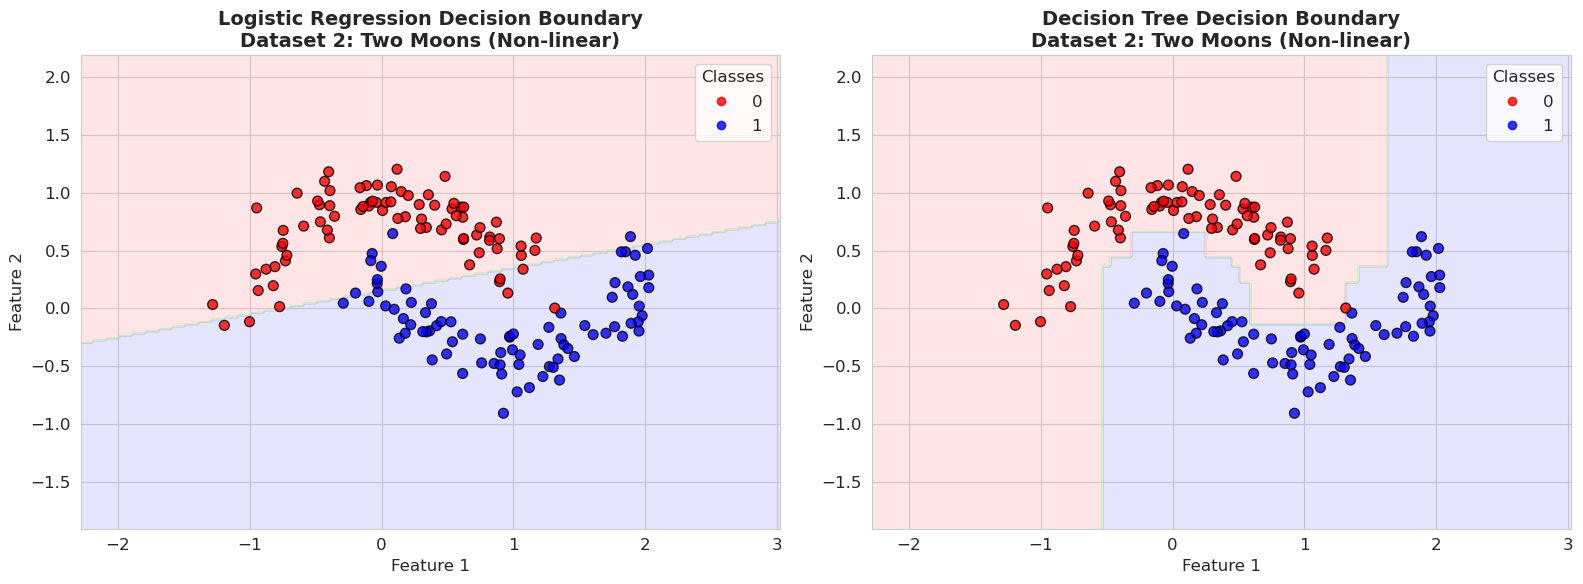

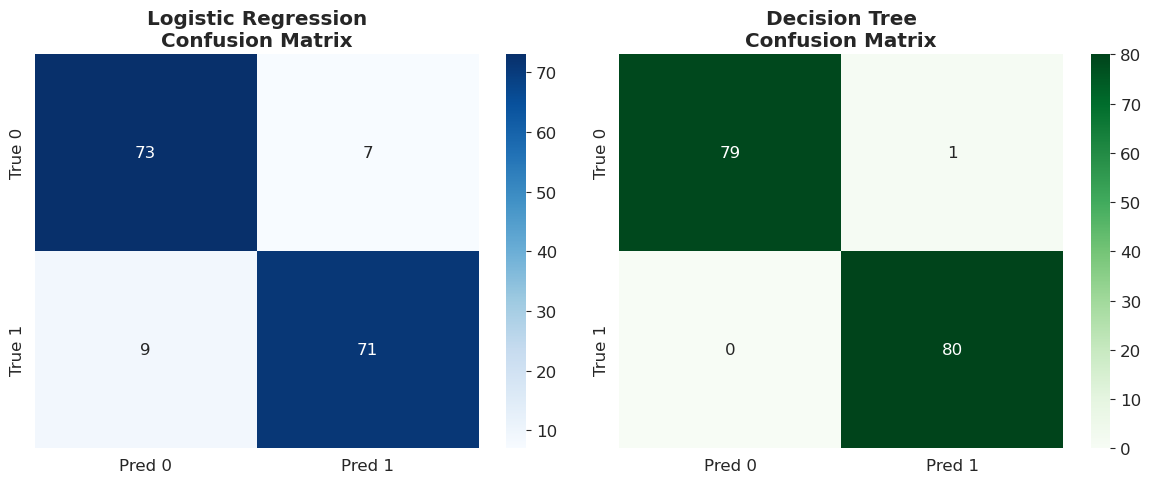

In [10]:
X2, y2 = make_moons(n_samples=800, noise=0.15, random_state=RANDOM_STATE)
results2 = run_experiment("Dataset 2: Two Moons (Non-linear)", X2, y2, use_poly=False)


Data split: Train=512, Val=128, Test=160


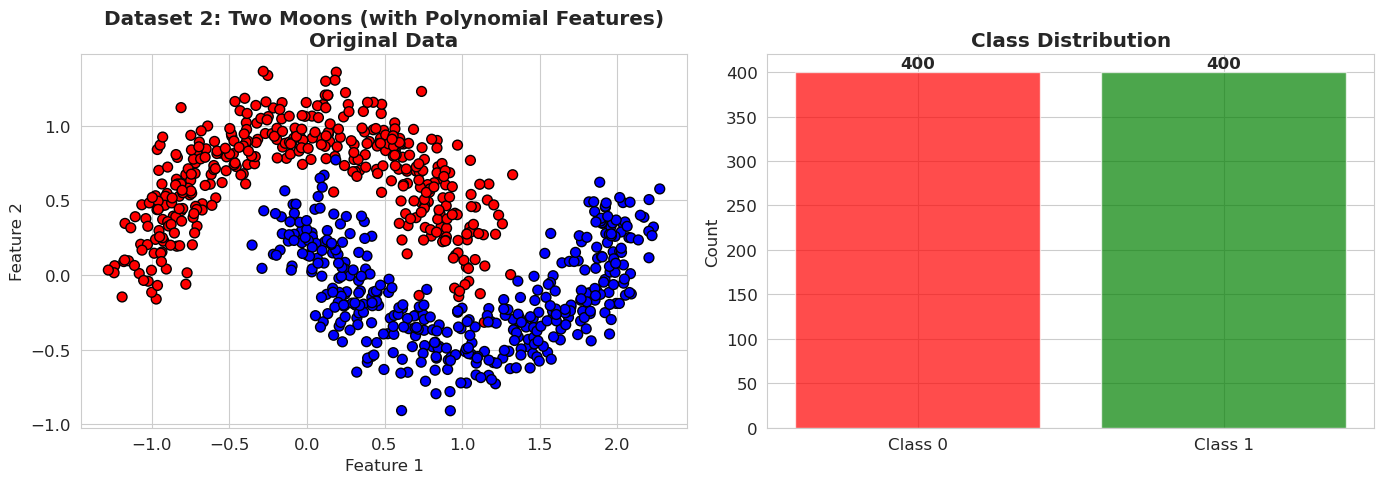

Best parameters: {'penalty': 'l1', 'C': 0.1}

Top 5 configurations:
penalty     C  train_accuracy  val_accuracy
     l1  0.10        0.875000      0.859375
     l1  1.00        0.871094      0.859375
     l1 10.00        0.882812      0.859375
     l2  0.01        0.871094      0.859375
     l2  0.10        0.882812      0.859375
Best parameters: {'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 4}

Top 5 configurations:
 max_depth  min_samples_split  min_samples_leaf  train_accuracy  val_accuracy
      12.0                  2                 4        0.994141      0.992188
      12.0                 10                 2        0.994141      0.992188
      10.0                  5                 4        0.994141      0.992188
       8.0                  5                 1        0.998047      0.992188
      15.0                  2                 4        0.994141      0.992188


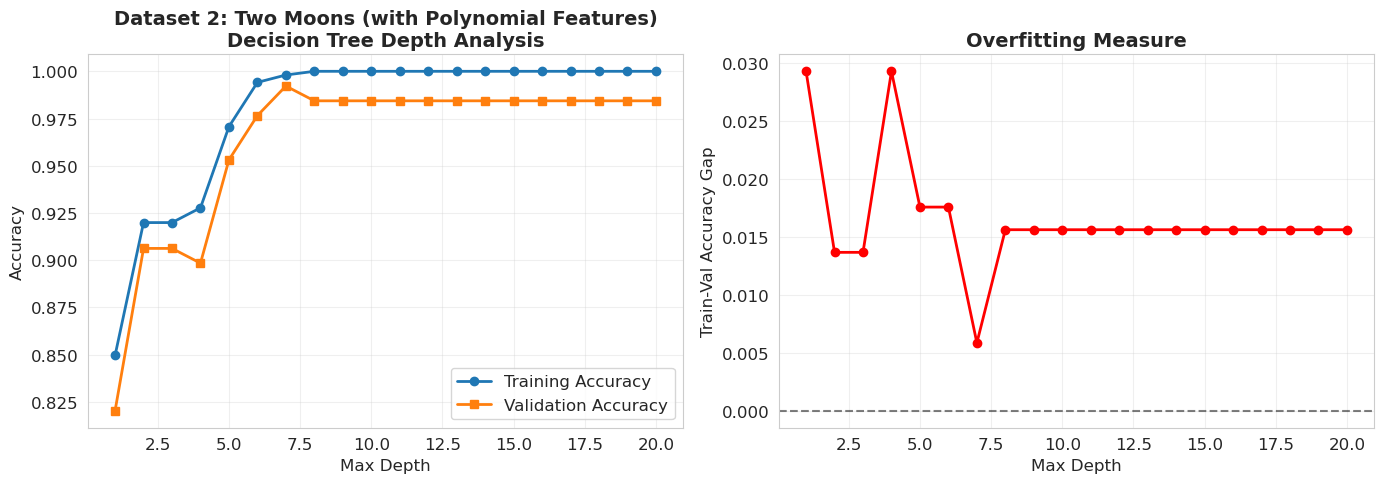

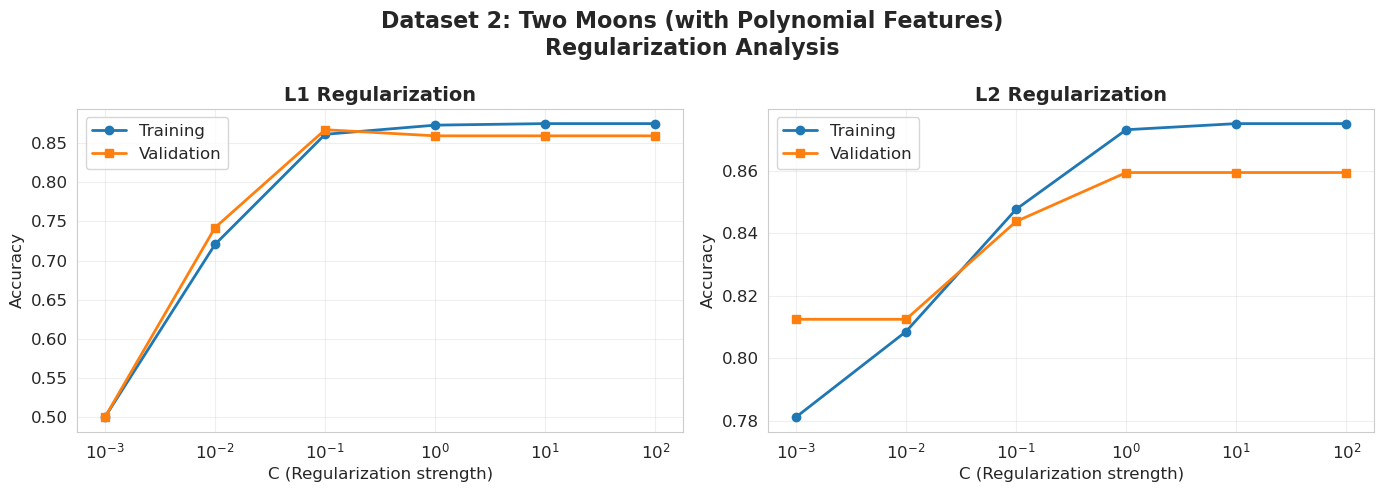


Logistic Regression Performance:
----------------------------------------
Accuracy: 0.9000
Precision: 0.9103
Recall: 0.8875
F1-Score: 0.8987

Confusion Matrix:
[[73  7]
 [ 9 71]]

Decision Tree Performance:
----------------------------------------
Accuracy: 0.9938
Precision: 0.9877
Recall: 1.0000
F1-Score: 0.9938

Confusion Matrix:
[[79  1]
 [ 0 80]]


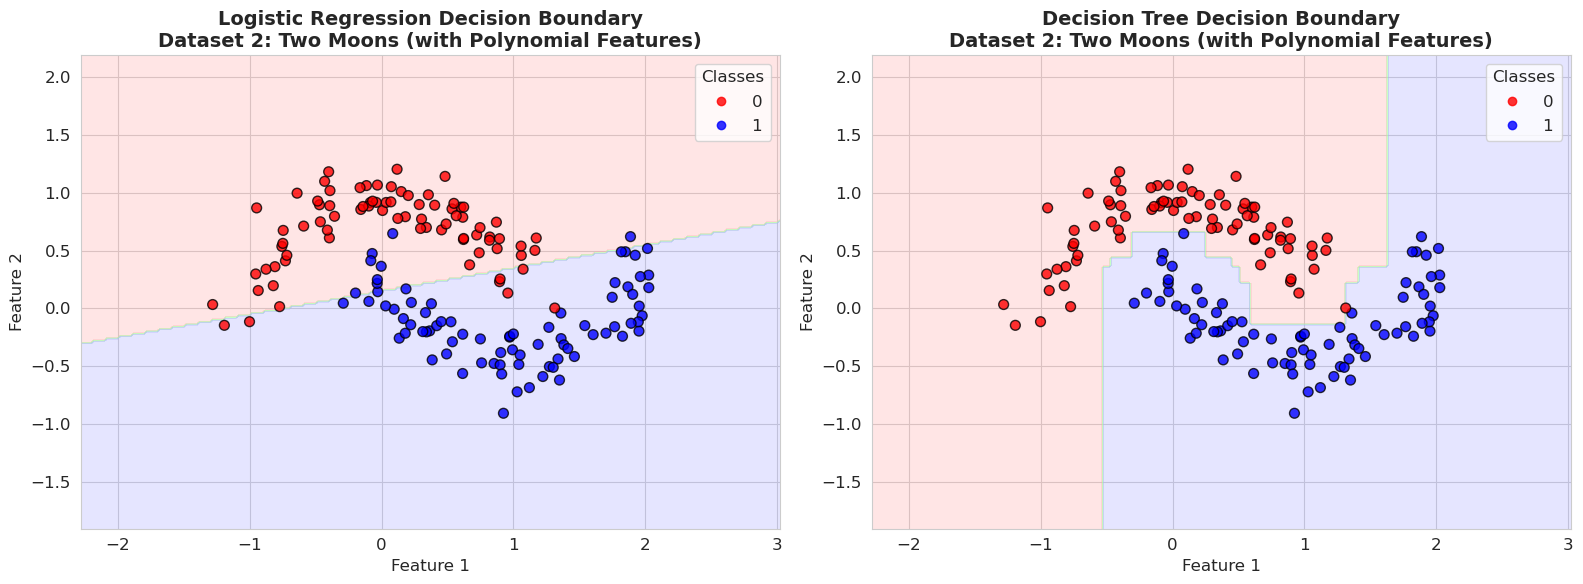

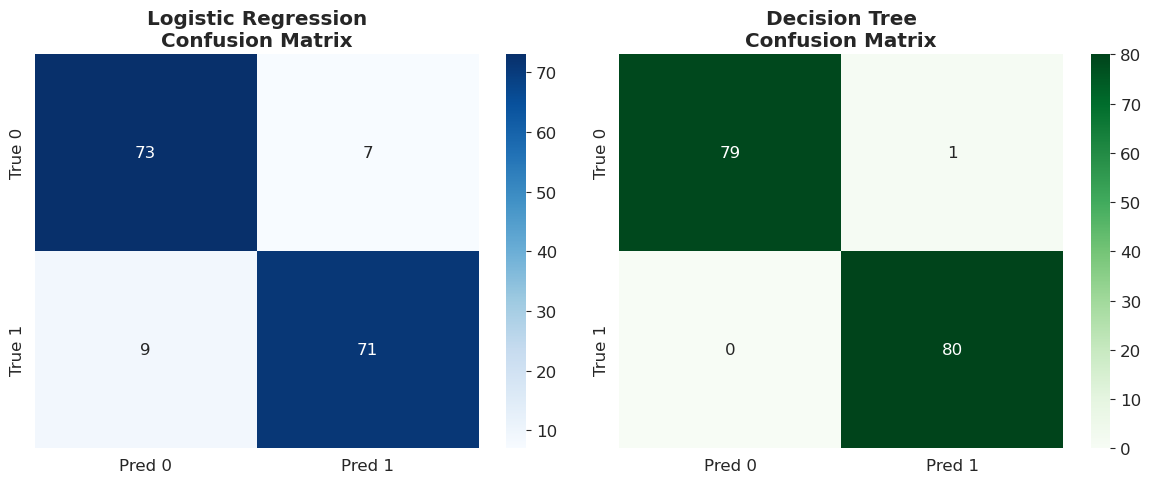

        Model  Accuracy  F1-Score
     Plain LR   0.90000  0.898734
Polynomial LR   0.90000  0.898734
Decision Tree   0.99375  0.993789


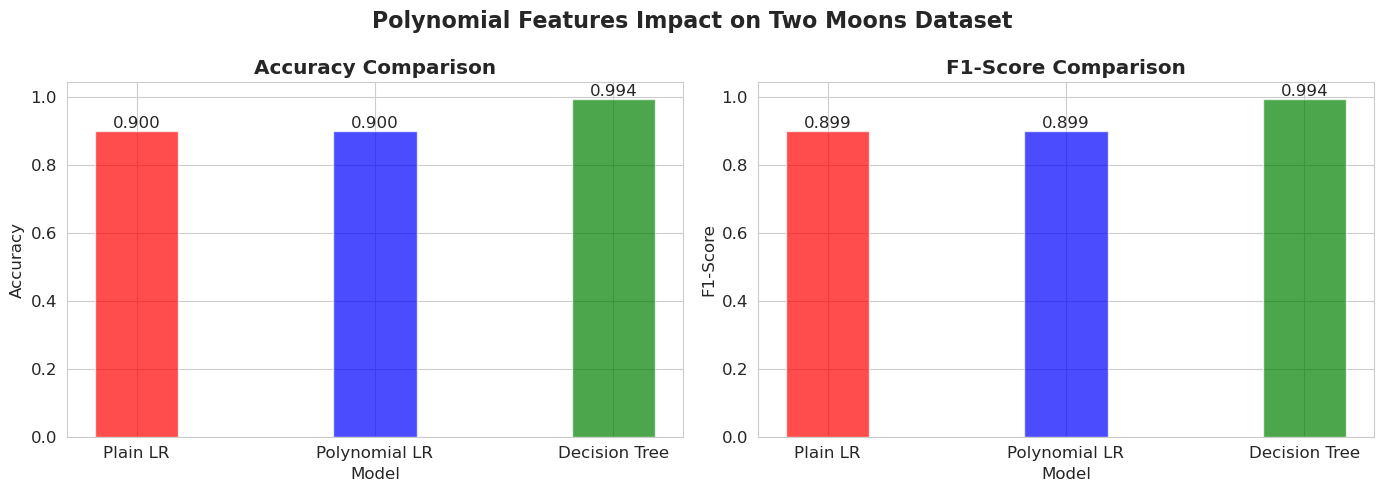

In [12]:
results2_poly = run_experiment("Dataset 2: Two Moons (with Polynomial Features)", X2, y2, use_poly=True) #degree=2

comparison_data = {
    'Model': ['Plain LR', 'Polynomial LR', 'Decision Tree'],
    'Accuracy': [results2['lr_metrics']['Accuracy'], 
                 results2_poly['lr_metrics']['Accuracy'],
                 results2['dt_metrics']['Accuracy']],
    'F1-Score': [results2['lr_metrics']['F1-Score'], 
                 results2_poly['lr_metrics']['F1-Score'],
                 results2['dt_metrics']['F1-Score']]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison_df['Model']))
width = 0.35

axes[0].bar(x, comparison_df['Accuracy'], width, color=['red', 'blue', 'green'], alpha=0.7)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].bar_label(axes[0].containers[0], fmt='%.3f')

axes[1].bar(x, comparison_df['F1-Score'], width, color=['red', 'blue', 'green'], alpha=0.7)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score Comparison', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'])
axes[1].bar_label(axes[1].containers[0], fmt='%.3f')

plt.suptitle('Polynomial Features Impact on Two Moons Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Added 50 outliers to the dataset
Total samples: 700

Data split: Train=448, Val=112, Test=140


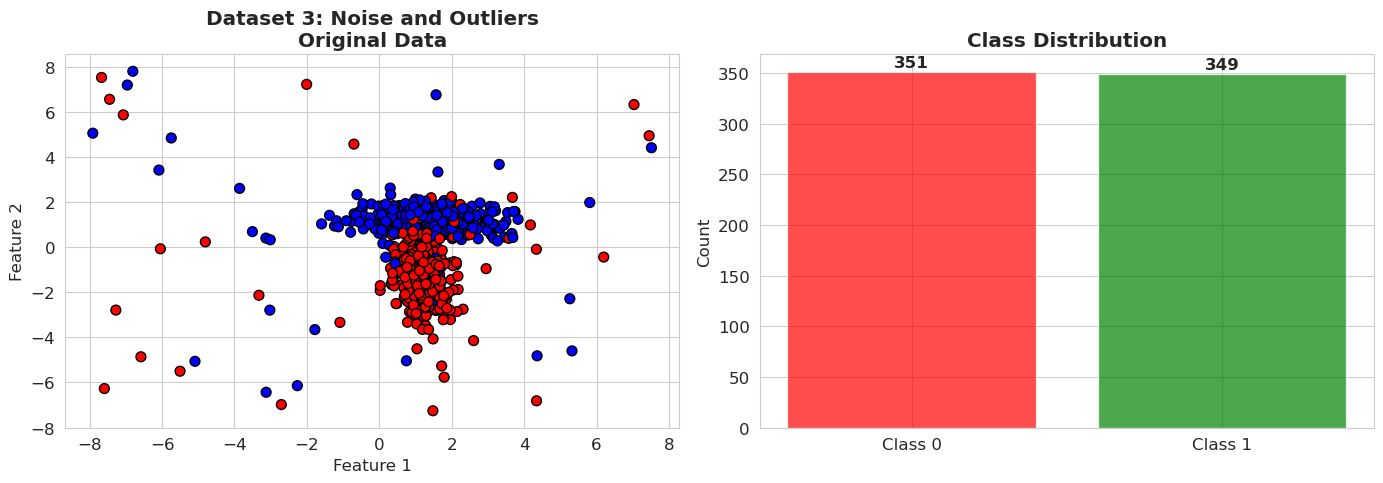

Best parameters: {'penalty': 'l1', 'C': 0.1}

Top 5 configurations:
penalty      C  train_accuracy  val_accuracy
     l1  0.100        0.868304      0.883929
     l1  1.000        0.872768      0.883929
     l1 10.000        0.872768      0.883929
     l2  0.001        0.866071      0.883929
     l2  0.100        0.870536      0.883929
Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 2}

Top 5 configurations:
 max_depth  min_samples_split  min_samples_leaf  train_accuracy  val_accuracy
       5.0                  5                 2        0.921875      0.910714
       5.0                  2                 2        0.921875      0.910714
       5.0                  2                 1        0.926339      0.901786
       5.0                  5                 1        0.921875      0.901786
       1.0                  2                 1        0.888393      0.892857


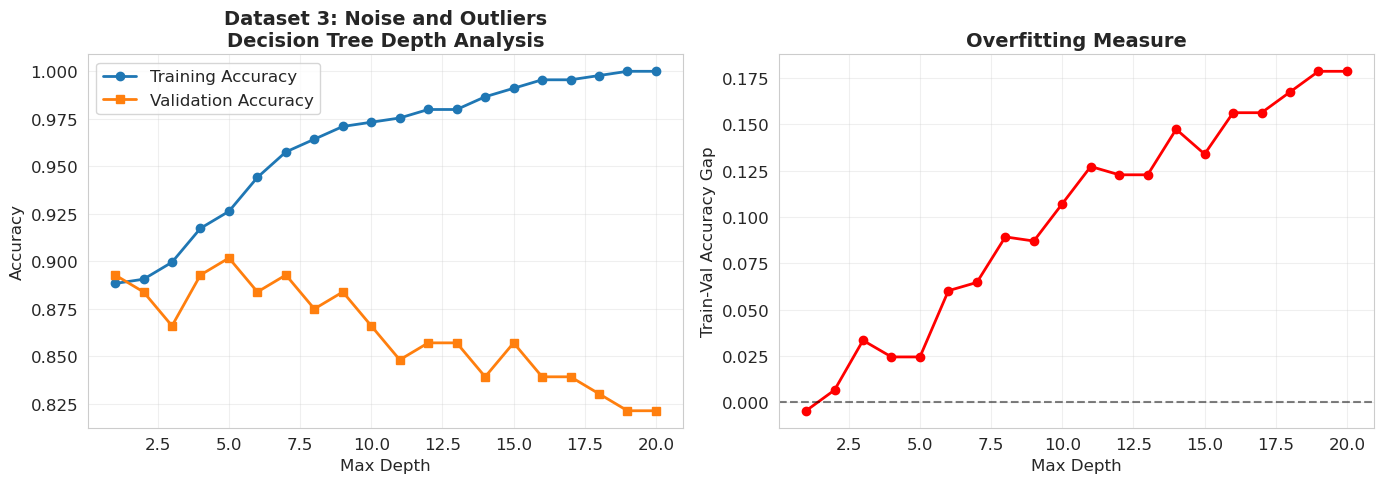

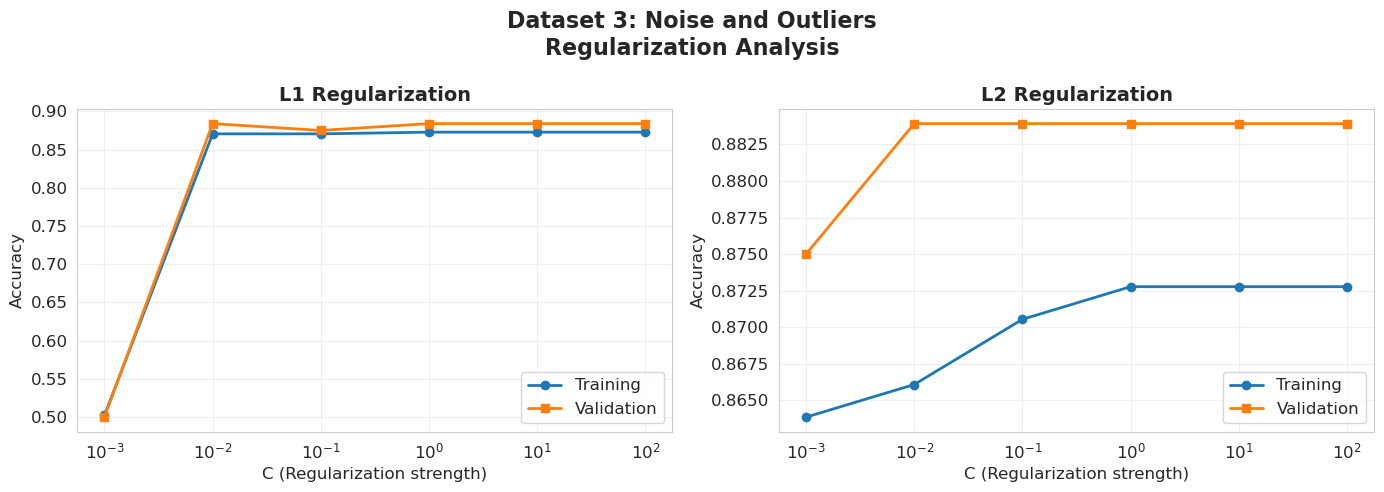


Logistic Regression Performance:
----------------------------------------
Accuracy: 0.8857
Precision: 0.8293
Recall: 0.9714
F1-Score: 0.8947

Confusion Matrix:
[[56 14]
 [ 2 68]]

Decision Tree Performance:
----------------------------------------
Accuracy: 0.8929
Precision: 0.8767
Recall: 0.9143
F1-Score: 0.8951

Confusion Matrix:
[[61  9]
 [ 6 64]]


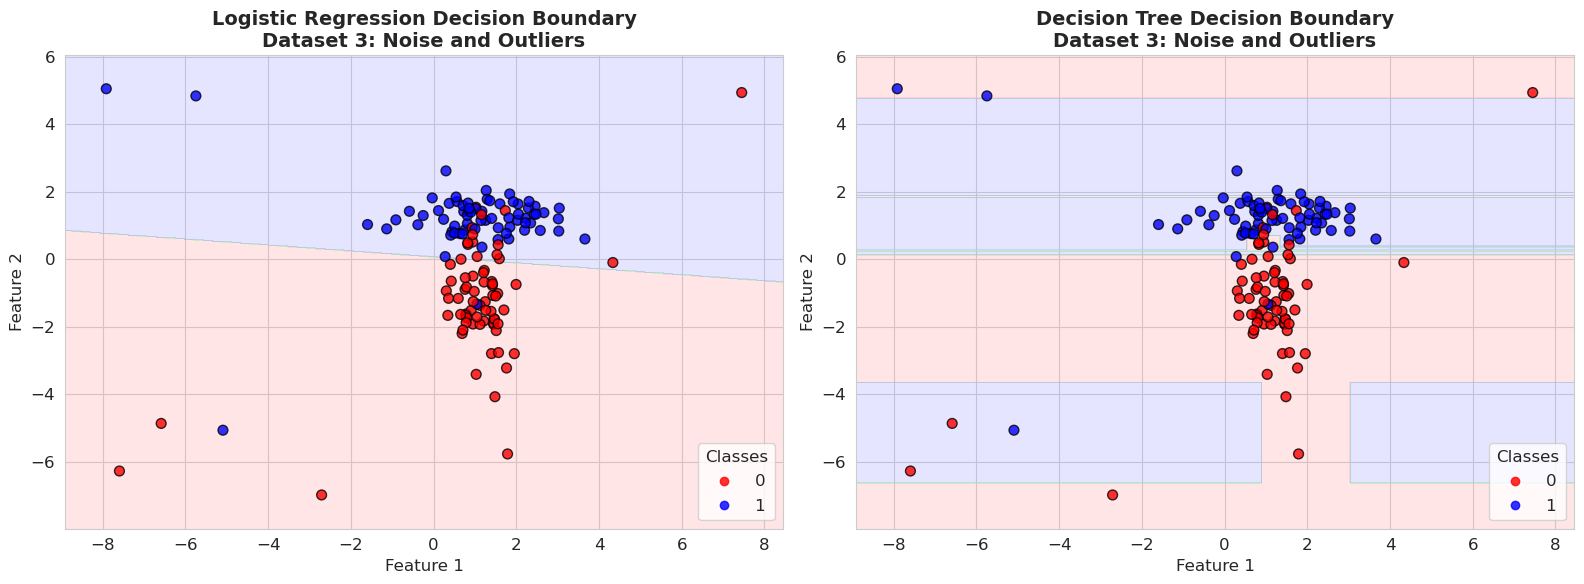

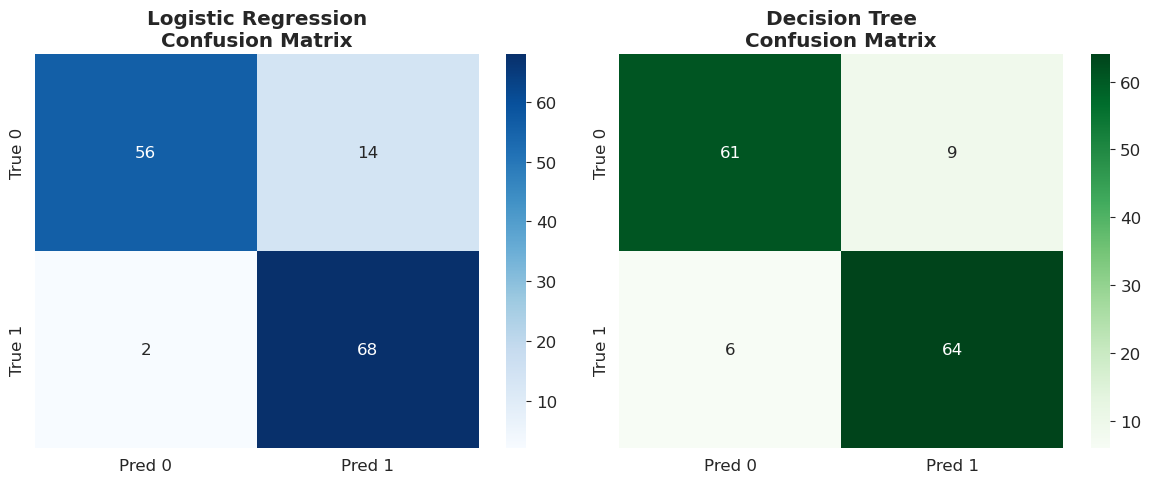

In [13]:
X3_base, y3_base = make_classification(
    n_samples=650,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    flip_y=0.08,  
    random_state=RANDOM_STATE
)

n_outliers = 50
outliers = np.random.uniform(low=-8, high=8, size=(n_outliers, 2))
outlier_labels = np.random.randint(0, 2, size=n_outliers)

X3 = np.vstack([X3_base, outliers])
y3 = np.concatenate([y3_base, outlier_labels])

print(f"Added {n_outliers} outliers to the dataset")
print(f"Total samples: {len(X3)}")

results3 = run_experiment("Dataset 3: Noise and Outliers", X3, y3, use_poly=False)


Data split: Train=576, Val=144, Test=180


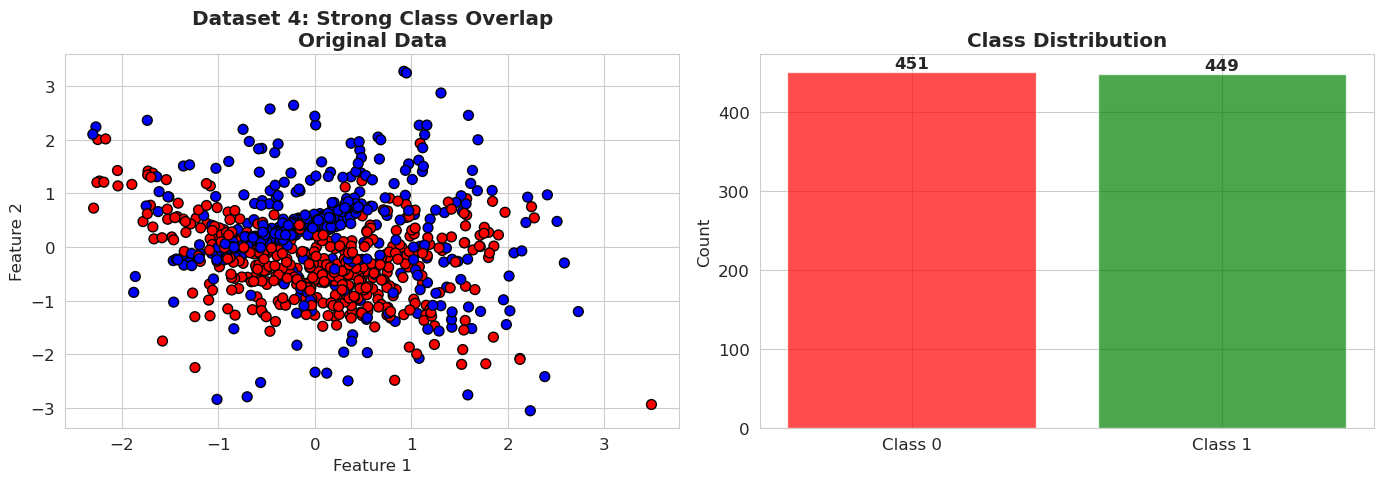

Best parameters: {'penalty': 'l2', 'C': 0.001}

Top 5 configurations:
penalty     C  train_accuracy  val_accuracy
     l2 0.001        0.687500      0.680556
     l1 0.100        0.682292      0.666667
     l1 1.000        0.664931      0.666667
     l2 0.010        0.677083      0.659722
     l2 0.100        0.666667      0.659722
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 1}

Top 5 configurations:
 max_depth  min_samples_split  min_samples_leaf  train_accuracy  val_accuracy
      15.0                 20                 1        0.862847      0.763889
       NaN                 20                 1        0.862847      0.763889
      10.0                  5                 1        0.927083      0.763889
       6.0                  5                 1        0.854167      0.756944
       6.0                  2                 2        0.848958      0.756944


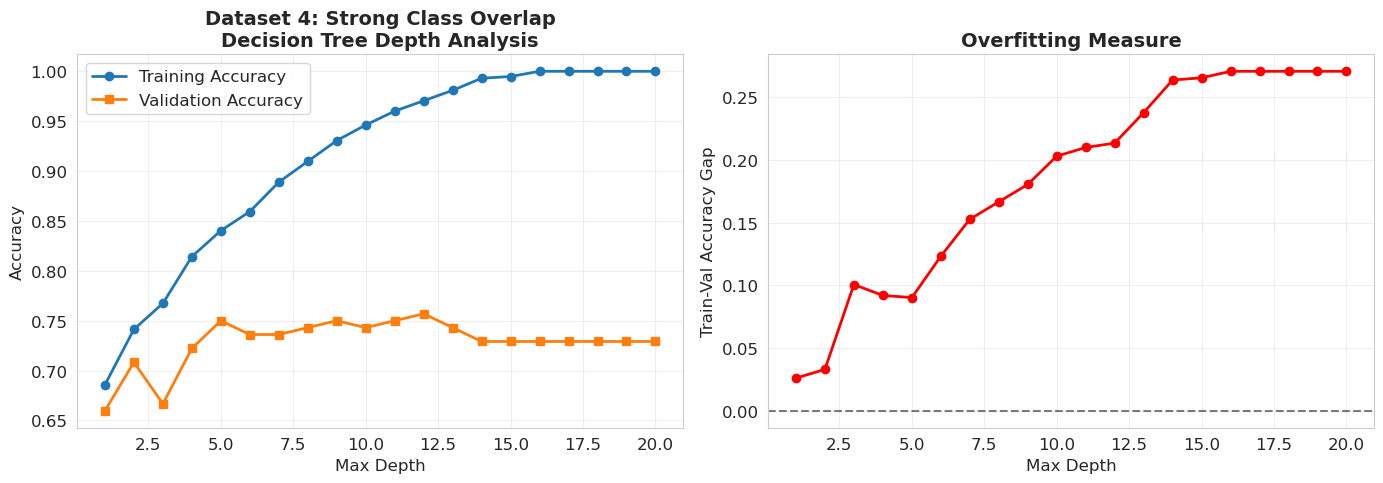

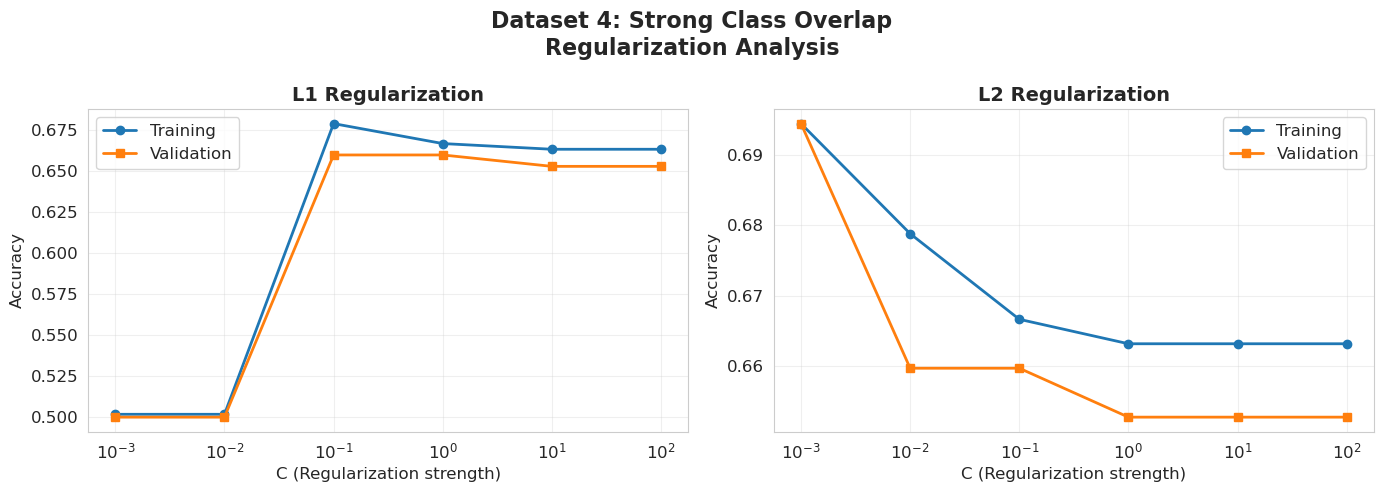


Logistic Regression Performance:
----------------------------------------
Accuracy: 0.6833
Precision: 0.6774
Recall: 0.7000
F1-Score: 0.6885

Confusion Matrix:
[[60 30]
 [27 63]]

Decision Tree Performance:
----------------------------------------
Accuracy: 0.7444
Precision: 0.7821
Recall: 0.6778
F1-Score: 0.7262

Confusion Matrix:
[[73 17]
 [29 61]]


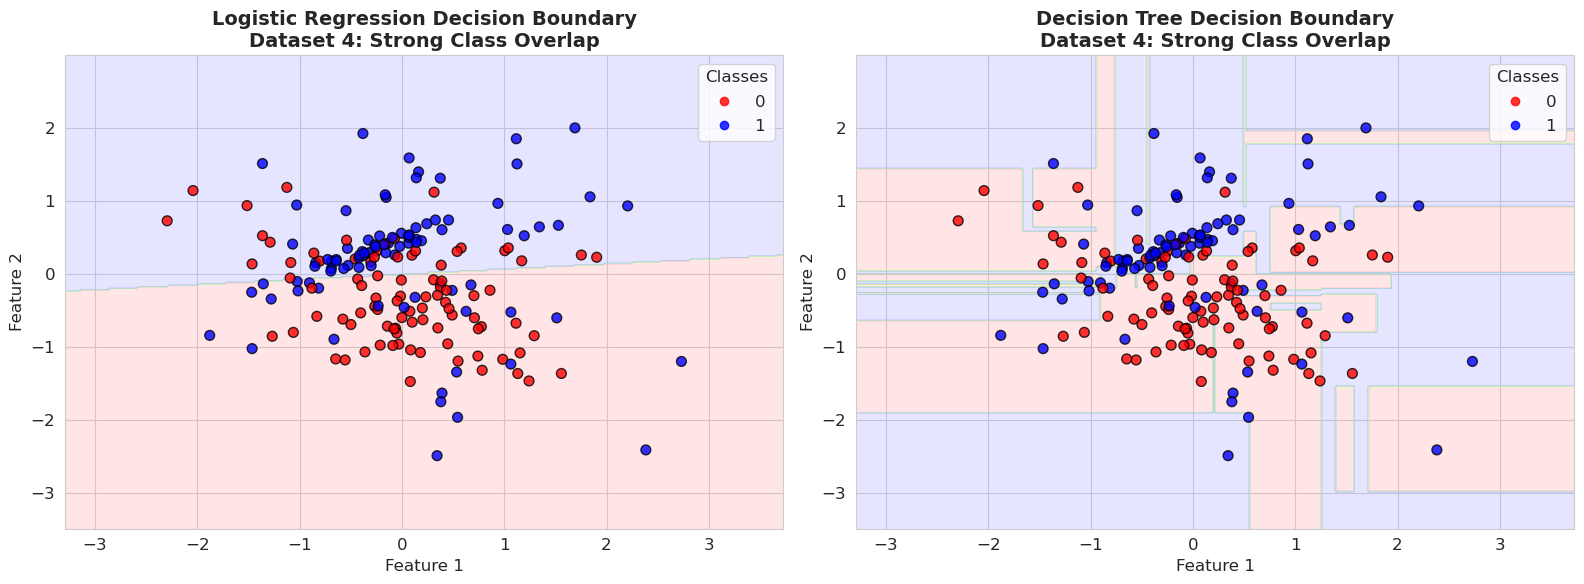

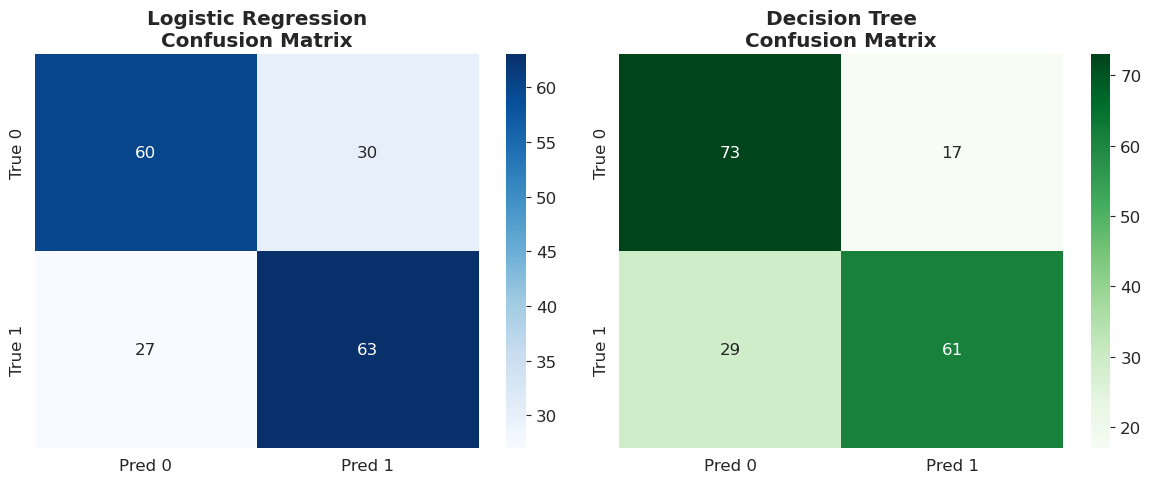

In [14]:
X4, y4 = make_classification(
    n_samples=900,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,
    class_sep=0.3,  
    flip_y=0.05,
    random_state=RANDOM_STATE
)

results4 = run_experiment("Dataset 4: Strong Class Overlap", X4, y4, use_poly=False)


Dataset Overview:
         x1        x2 category
0  0.596057  0.938284        D
1 -0.165917 -0.516045        B
2  0.777226  0.096121        A
3  1.827636 -0.462275        D
4 -0.280984 -0.434496        A
5 -0.280964 -0.309172        B
6  1.895055  0.222134        A
7  0.920922 -0.478749        B
8 -0.563369  1.255756        D
9  0.651072 -0.894607        C

Class distribution:
0    405
1    395
Name: count, dtype: int64


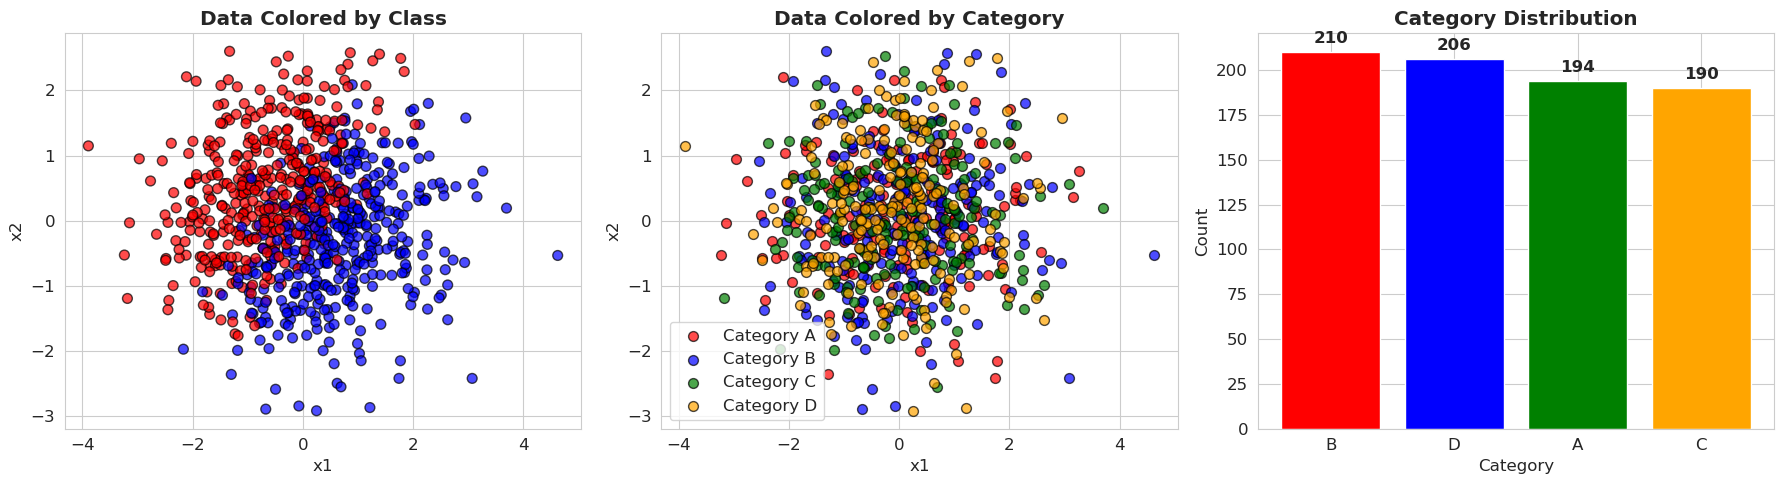

Best parameters: {'penalty': 'l2', 'C': 1}

Top 5 configurations:
penalty    C  train_accuracy  val_accuracy
     l2  1.0        0.945312      0.960938
     l1  1.0        0.951172      0.953125
     l1 10.0        0.953125      0.953125
     l2 10.0        0.951172      0.953125
     l2  0.1        0.919922      0.937500
Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2}

Top 5 configurations:
 max_depth  min_samples_split  min_samples_leaf  train_accuracy  val_accuracy
        10                  2                 2        0.972656      0.945312
        12                  2                 2        0.972656      0.945312
         8                  2                 1        0.988281      0.937500
         8                  5                 2        0.958984      0.937500
         8                  5                 1        0.968750      0.937500

Logistic Regression (with categories) Performance:
----------------------------------------
Accuracy: 

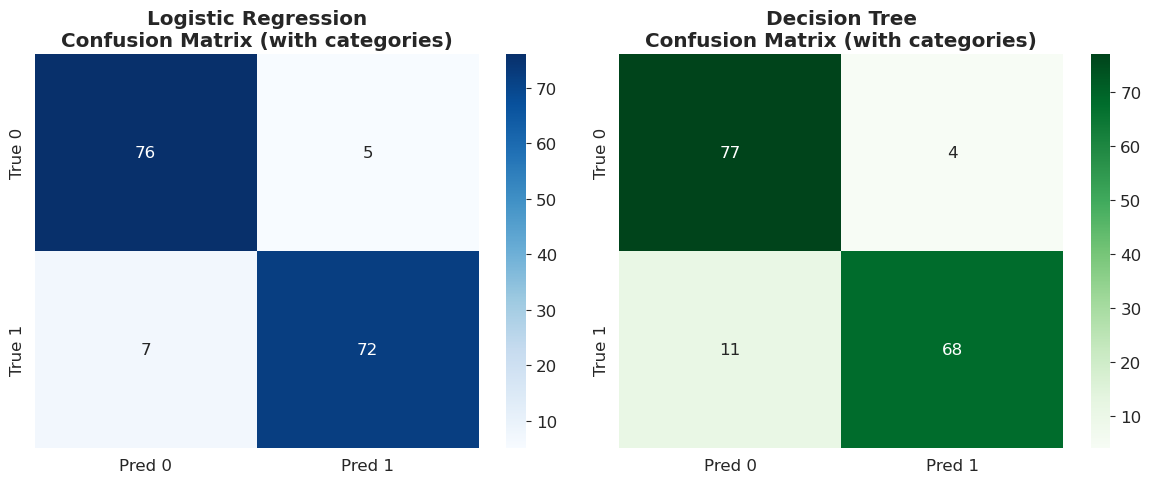

In [15]:
n_samples = 800
np.random.seed(RANDOM_STATE)

x1 = np.random.normal(0, 1.2, n_samples)
x2 = np.random.normal(0, 1.0, n_samples)

categories = ['A', 'B', 'C', 'D']
category_probs = [0.25, 0.25, 0.25, 0.25]
category = np.random.choice(categories, size=n_samples, p=category_probs)

shift_map = {'A': 0.8, 'B': -0.5, 'C': 1.2, 'D': -1.0}
shifts = np.array([shift_map[cat] for cat in category])

logit = 1.4 * x1 - 1.1 * x2 + shifts + np.random.normal(0, 0.5, n_samples)
y5 = (logit > 0).astype(int)

X5_df = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'category': category
})

print("\nDataset Overview:")
print(X5_df.head(10))
print(f"\nClass distribution:\n{pd.Series(y5).value_counts().sort_index()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X5_df['x1'], X5_df['x2'], c=y5, cmap=cmap_bold, 
                edgecolor='black', s=50, alpha=0.7)
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('Data Colored by Class', fontweight='bold')

category_colors = {'A': 'red', 'B': 'blue', 'C': 'green', 'D': 'orange'}

for cat in categories:
    mask = X5_df['category'] == cat
    axes[1].scatter(X5_df.loc[mask, 'x1'], X5_df.loc[mask, 'x2'], c=category_colors[cat], label=f'Category {cat}', edgecolor='black', s=50, alpha=0.7)
    
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].set_title('Data Colored by Category', fontweight='bold')
axes[1].legend()

cat_counts = X5_df['category'].value_counts()
axes[2].bar(cat_counts.index, cat_counts.values, color=['red', 'blue', 'green', 'orange'])
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Count')
axes[2].set_title('Category Distribution', fontweight='bold')

for i, v in enumerate(cat_counts.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

X5 = X5_df.copy()
y5 = y5

X_train, X_val, X_test, y_train, y_val, y_test = create_train_val_test_split(X5, y5)

numeric_features = ['x1', 'x2']
categorical_features = ['category']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

lr_results = []
best_lr = None
best_lr_score = -1
best_lr_params = None

for penalty in ['l1', 'l2']:
    for C in [0.001, 0.01, 0.1, 1, 10]:
        lr_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(penalty=penalty, C=C, solver='liblinear',
                                             max_iter=1000, random_state=RANDOM_STATE))
        ])
        
        lr_pipeline.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, lr_pipeline.predict(X_train))
        val_acc = accuracy_score(y_val, lr_pipeline.predict(X_val))
        
        lr_results.append({
            'penalty': penalty,
            'C': C,
            'train_accuracy': train_acc,
            'val_accuracy': val_acc
        })
        
        if val_acc > best_lr_score:
            best_lr_score = val_acc
            best_lr = lr_pipeline
            best_lr_params = {'penalty': penalty, 'C': C}

lr_results_df = pd.DataFrame(lr_results).sort_values('val_accuracy', ascending=False)
print(f"Best parameters: {best_lr_params}")
print("\nTop 5 configurations:")
print(lr_results_df.head(5).to_string(index=False))

dt_results = []
best_dt = None
best_dt_score = -1
best_dt_params = None

dt_preprocessor = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

for max_depth in [1, 2, 3, 4, 5, 6, 8, 10, 12]:
    for min_samples_split in [2, 5, 10]:
        for min_samples_leaf in [1, 2, 4]:
            dt_pipeline = Pipeline([
                ('preprocessor', dt_preprocessor),
                ('classifier', DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    random_state=RANDOM_STATE
                ))
            ])
            
            dt_pipeline.fit(X_train, y_train)
            train_acc = accuracy_score(y_train, dt_pipeline.predict(X_train))
            val_acc = accuracy_score(y_val, dt_pipeline.predict(X_val))
            
            dt_results.append({
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'train_accuracy': train_acc,
                'val_accuracy': val_acc
            })
            
            if val_acc > best_dt_score:
                best_dt_score = val_acc
                best_dt = dt_pipeline
                best_dt_params = {
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'min_samples_leaf': min_samples_leaf
                }

dt_results_df = pd.DataFrame(dt_results).sort_values('val_accuracy', ascending=False)
print(f"Best parameters: {best_dt_params}")
print("\nTop 5 configurations:")
print(dt_results_df.head(5).to_string(index=False))

y_pred_lr_cat = best_lr.predict(X_test)
lr_metrics_cat, lr_cm_cat = evaluate_model(y_test, y_pred_lr_cat, "Logistic Regression (with categories)")

y_pred_dt_cat = best_dt.predict(X_test)
dt_metrics_cat, dt_cm_cat = evaluate_model(y_test, y_pred_dt_cat, "Decision Tree (with categories)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(lr_cm_cat, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[0].set_title('Logistic Regression\nConfusion Matrix (with categories)', fontweight='bold')

sns.heatmap(dt_cm_cat, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[1].set_title('Decision Tree\nConfusion Matrix (with categories)', fontweight='bold')

plt.tight_layout()
plt.show()

results5 = {
    'dataset_name': 'Dataset 5: Categorical Features',
    'best_lr': best_lr,
    'best_dt': best_dt,
    'lr_params': best_lr_params,
    'dt_params': best_dt_params,
    'lr_metrics': lr_metrics_cat,
    'dt_metrics': dt_metrics_cat,
    'lr_results': lr_results_df,
    'dt_results': dt_results_df,
    'X_test': X_test,
    'y_test': y_test,
    'y_pred_lr': y_pred_lr_cat,
    'y_pred_dt': y_pred_dt_cat
}

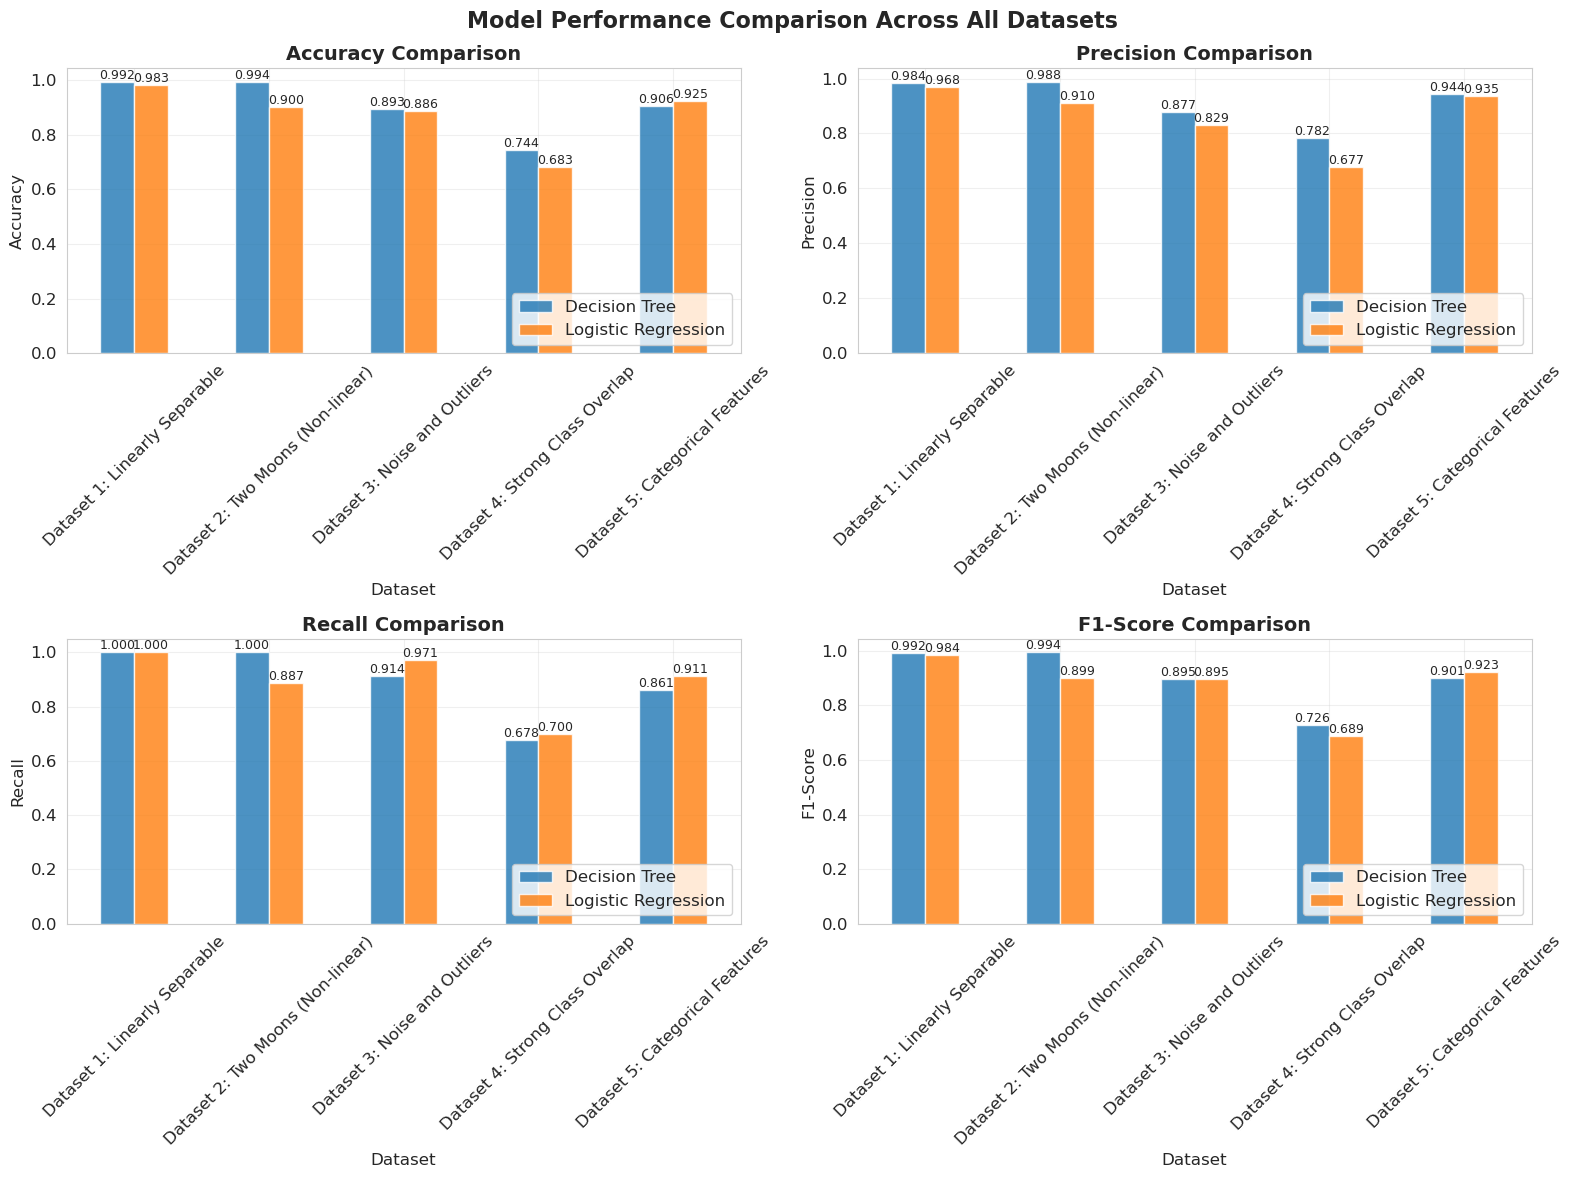


Detailed Summary Table:
                          Dataset               Model  Accuracy  Precision   Recall  F1-Score
    Dataset 1: Linearly Separable Logistic Regression  0.983333   0.967742 1.000000  0.983607
    Dataset 1: Linearly Separable       Decision Tree  0.991667   0.983607 1.000000  0.991736
Dataset 2: Two Moons (Non-linear) Logistic Regression  0.900000   0.910256 0.887500  0.898734
Dataset 2: Two Moons (Non-linear)       Decision Tree  0.993750   0.987654 1.000000  0.993789
    Dataset 3: Noise and Outliers Logistic Regression  0.885714   0.829268 0.971429  0.894737
    Dataset 3: Noise and Outliers       Decision Tree  0.892857   0.876712 0.914286  0.895105
  Dataset 4: Strong Class Overlap Logistic Regression  0.683333   0.677419 0.700000  0.688525
  Dataset 4: Strong Class Overlap       Decision Tree  0.744444   0.782051 0.677778  0.726190
  Dataset 5: Categorical Features Logistic Regression  0.925000   0.935065 0.911392  0.923077
  Dataset 5: Categorical Features  

In [16]:
all_results = [results1, results2, results3, results4, results5]
summary_df = create_summary_table(all_results)

print("\nDetailed Summary Table:")
print(summary_df.to_string(index=False))

winners = []
for dataset in summary_df['Dataset'].unique():
    dataset_results = summary_df[summary_df['Dataset'] == dataset]
    best_f1_idx = dataset_results['F1-Score'].idxmax()
    winners.append({
        'Dataset': dataset,
        'Best Model': dataset_results.loc[best_f1_idx, 'Model'],
        'F1-Score': dataset_results.loc[best_f1_idx, 'F1-Score'],
        'Accuracy': dataset_results.loc[best_f1_idx, 'Accuracy']
    })

winners_df = pd.DataFrame(winners)
print(winners_df.to_string(index=False))

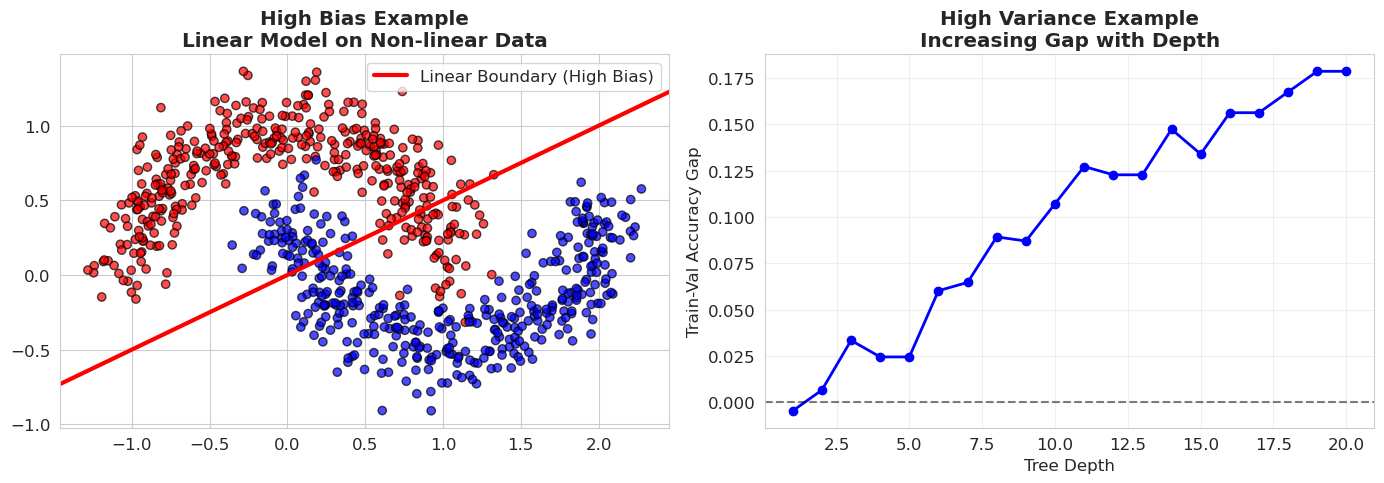

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X2[:, 0], X2[:, 1], c=y2, cmap=cmap_bold, edgecolor='black', alpha=0.7)
x_range = np.linspace(X2[:, 0].min(), X2[:, 0].max(), 100)

axes[0].axline((0, 0), slope=0.5, color='red', linewidth=3, label='Linear Boundary (High Bias)')
axes[0].set_title('High Bias Example\nLinear Model on Non-linear Data', fontweight='bold')
axes[0].legend()

depth_vals = results3['depth_df']['Depth']
gap_vals = results3['depth_df']['Gap']
axes[1].plot(depth_vals, gap_vals, 'bo-', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Tree Depth')
axes[1].set_ylabel('Train-Val Accuracy Gap')
axes[1].set_title('High Variance Example\nIncreasing Gap with Depth', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
summary_df.to_csv('ML_proj_comparison_table.csv', index=False)
print("Results saved to 'model_comparison_results.csv'")

Results saved to 'model_comparison_results.csv'
